In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

This is an EDA about Renewable Energy in California. We are diving into questions that suggest at what optimal conditions does renewable energy rise such as with humidity, temperature, Wind Speed, etc.

The Questions we are going to be focusing on today are 5 Main Questions:

1. Wind Speed
2. Humidity
3. Temperature
4. Solar Radiation (DHI, DNI, and GHI) across Multiple Seasons
5. Whata seasons are meant for solar or wind.

In [4]:
# Processing and loading

dataset = pd.read_csv("Database.csv")
print(dataset.head())
print(dataset.info())

def process_data(data):
    data.columns = data.columns.str.strip()
    data = data.dropna().drop_duplicates()
    data['Time'] = data['Time'].astype(str).str.strip()
    data['Time'] = pd.to_datetime(data['Time'], format='%Y-%m-%d-T%H:%M')
    return data

def average(data, column_one, column_two):
    # 1. Create the aggregated averages dataframe
    df_indexed = data.set_index('Time').sort_index()
    
    daily = df_indexed[[column_one, column_two]].resample('D').mean()
    
    weekly = daily.rolling(window=7, min_periods=1, center=True).mean()
    monthly = daily.rolling(window=30, min_periods=1, center=True).mean()
    
    # 2. Rename columns in the aggregates to match your desired output
    daily = daily.rename(columns={column_one: f'{column_one}_daily', column_two: f'{column_two}_daily'})
    weekly = weekly.rename(columns={column_one: f'{column_one}_weekly', column_two: f'{column_two}_weekly'})
    monthly = monthly.rename(columns={column_one: f'{column_one}_monthly', column_two: f'{column_two}_monthly'})
    
    # Combine all aggregates into a single lookup table
    averages_df = daily.join([weekly, monthly])

    # We temporarily create a key column to merge on
    data['date_floor'] = data['Time'].dt.floor('D')
    
    data = data.merge(averages_df, left_on='date_floor', right_index=True, how='left')
    
    # Drop the temporary merging key
    data.drop(columns=['date_floor'], inplace=True)
    
    return data

processed_data = process_data(dataset)
print(processed_data.head())
print(processed_data.info())


           Time               Season  Day_of_the_week  DHI    DNI    GHI     \
0      0   2019-01-01-T00:00       1                1    0.0    0.0     0.0   
1      1   2019-01-01-T00:05       1                1    0.0    0.0     0.0   
2      2   2019-01-01-T00:10       1                1    0.0    0.0     0.0   
3      3   2019-01-01-T00:15       1                1    0.0    0.0     0.0   
4      4   2019-01-01-T00:20       1                1    0.0    0.0     0.0   

   Wind_speed          Humidity            Temperature            \
0                2.88              56.036                   1.82   
1                2.88              56.036                   1.82   
2                2.88              56.194                   1.78   
3                2.88              56.344                   1.74   
4                2.84              56.440                   1.72   

   PV_production  Wind_production  Electric_demand  
0              0             2810            22216  
1         

Question 1: How does Wind Speed affect Wind Power Usage?

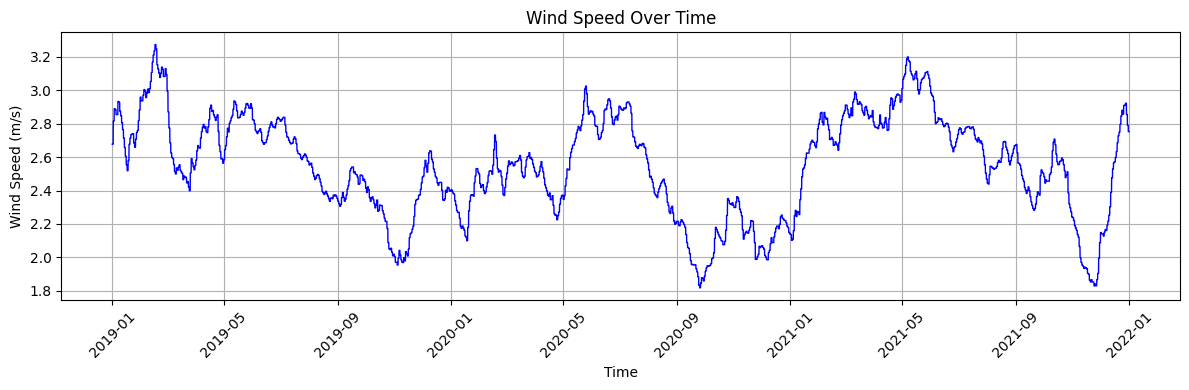

<Figure size 640x480 with 0 Axes>

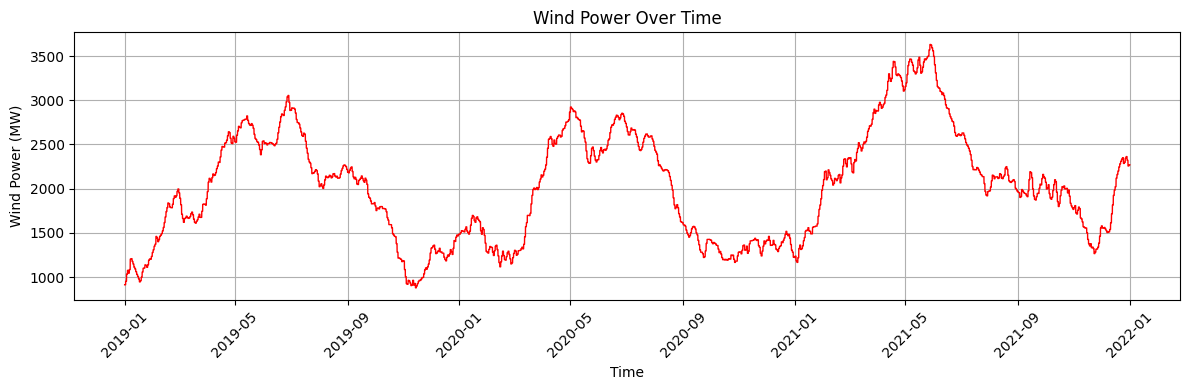

<Figure size 640x480 with 0 Axes>

In [ ]:
# Graphing

wind_data = average(processed_data, 'Wind_speed', 'Wind_production')

# Wind Speed Graph
x_axis = wind_data['Time']
y_axis = wind_data['Wind_speed_monthly']
plt.figure(figsize=(12, 4))
plt.plot(x_axis, y_axis, color='blue', linewidth=1)
plt.title('Wind Speed Over Time')
plt.xlabel('Time')
plt.ylabel('Wind Speed (m/s)')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()
plt.clf()

# Wind Power Over Time Graph
x_axis = wind_data['Time']
y_axis = wind_data['Wind_production_monthly']
plt.figure(figsize=(12, 4))
plt.plot(x_axis, y_axis, color='red', linewidth=1)
plt.title('Wind Power Over Time')
plt.xlabel('Time')
plt.ylabel('Wind Power (MW)')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()
plt.clf()

As we can see from this graph, wind power wasn't correlated with wind speed until Sepetember 2019, when since then, it has correlated with Wind Speed to some extent.